# Análise Exploratória de Dados — Steam (Dataset V2)
### TCC — Análise Preditiva da Popularidade de Jogos na Steam Utilizando Redes Neurais

Objetivo

Este relatório documenta a Análise Exploratória de Dados  realizada sobre o conjunto de dados de jogos coletados da plataforma Steam.
O objetivo central é compreender o comportamento das variáveis disponíveis, identificar padrões relevantes e fundamentar as decisões de pré-processamento e arquitetura do modelo preditivo baseado em Redes Neurais Artificiais.

## Estrutura do Relatório

1. Carregamento e Configuração
2. Visão Geral do Dataset
3. Análise de Completude dos Dados
4. Variável-Alvo: Popularidade (`reviews_total`)
5. Análise Univariada das Variáveis Numéricas
6. Análise de Gêneros
7. Análise de Categorias e Características de Jogabilidade
8. Análise de Plataformas
9. Análise Temporal (Lançamentos por Ano)
10. Análise de Sentimento do Público (`review_score_desc`)
11. Análise de Correlações
12. Síntese e Recomendações para a Modelagem



---
## 1. Carregamento e Configuração

Importação das bibliotecas necessárias e carregamento do dataset curado gerado pelo pipeline de coleta e processamento (`steam-analise-v2.py`).


In [48]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# isso aqui é só fru fru pros gráficos
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
sns.set_style("ticks")
PALETTE = "steelblue"

df = pd.read_csv("steam-jogos-v2.csv", low_memory=False)
print(f"  Dimensões : {df.shape[0]:,} jogos × {df.shape[1]} colunas")


  Dimensões : 118,537 jogos × 51 colunas


---
##  Visão Geral do Dataset


In [49]:
# Tipos de dados por coluna
print("── Tipos de Dados ──")
print(df.dtypes.to_string())


── Tipos de Dados ──
appid                               int64
name                                  str
type                                  str
is_free                              bool
price_brl                         float64
reviews_total                     float64
reviews_positive                  float64
reviews_negative                  float64
review_score                      float64
review_score_desc                     str
recommendations_total             float64
achievements_total                float64
required_age                        int64
metacritic_score                  float64
supported_languages_count           int64
dlc_count                           int64
has_demos                            bool
windows                              bool
mac                                  bool
linux                                bool
release_date                          str
genre_action                         bool
genre_adventure                      bool
genre_casual 

In [50]:
# Amostra das primeiras linhas (colunas essenciais)
cols_amostra = ["appid", "name", "is_free", "price_brl",
                "reviews_total", "reviews_positive", "reviews_negative",
                "review_score_desc", "release_year"]
print("── Amostra (primeiras 5 linhas) ──")
df[cols_amostra].head()


── Amostra (primeiras 5 linhas) ──


,appid,name,is_free,price_brl,reviews_total,reviews_positive,reviews_negative,review_score_desc,release_year
0,2621440,Infinity Castle Dungeon,False,13.79,32.0,27.0,5.0,Positive,2024.0
1,1048580,Terje Haakonsen's Powder VR,False,37.99,56.0,39.0,17.0,Mixed,2020.0
2,2097160,Monster Mystery,True,0.00,0.0,0.0,0.0,No user reviews,2022.0
3,10,Counter-Strike,False,20.69,168343.0,163264.0,5079.0,Overwhelmingly Positive,2000.0
4,3145740,VRider SBK™,False,59.62,18.0,9.0,9.0,Mixed,2025.0


In [51]:
# Estatísticas descritivas das variáveis numéricas
cols_num = ["price_brl", "reviews_total", "reviews_positive", "reviews_negative",
            "achievements_total", "required_age", "dlc_count",
            "supported_languages_count", "metacritic_score"]
df[cols_num].describe().round(2)


,price_brl,reviews_total,reviews_positive,reviews_negative,achievements_total,required_age,dlc_count,supported_languages_count,metacritic_score
count,118537.00,118537.00,118537.00,118537.00,118537.00,118537.00,118537.00,118537.00,4079.00
mean,175.66,927.08,809.04,118.04,19.33,2.32,0.50,5.79,73.83
std,5700.05,20901.22,18096.14,3555.39,143.63,5.21,12.21,14.32,10.24
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.00
25%,3.49,1.00,1.00,0.00,0.00,0.00,0.00,1.00,68.00
50%,13.79,8.00,6.00,1.00,6.00,0.00,0.00,1.00,75.00
75%,26.49,48.00,36.00,10.00,20.00,0.00,0.00,5.00,81.00
max,585000.00,5136950.00,4386336.00,777307.00,9821.00,21.00,3782.00,103.00,97.00


---
## Análise de Completude dos Dados


- **`reviews_total`, `reviews_positive`, `reviews_negative`**: valores ausentes foram imputados com `0`, pois a ausência do bloco `recommendations` na API da Steam indica zero avaliações registradas.
- **`achievements_total`**: imputado com `0` quando ausente, pois jogos sem o campo `achievements` não possuem sistema de conquistas.
- **`price_brl`**: jogos gratuitos (`is_free = True`) receberam preço `0.0`; jogos pagos sem preço listado foram removidos por indicarem indisponibilidade na loja.
- **`metacritic_score`**: a alta taxa de ausência é esperada, pois a vasta maioria dos jogos da Steam (especialmente títulos independentes) não possui avaliação no Metacritic.


                       Faltantes  % do Total
metacritic_score          114458       96.56
recommendations_total      97333       82.11
review_ratio               24420       20.60
review_score                 668        0.56


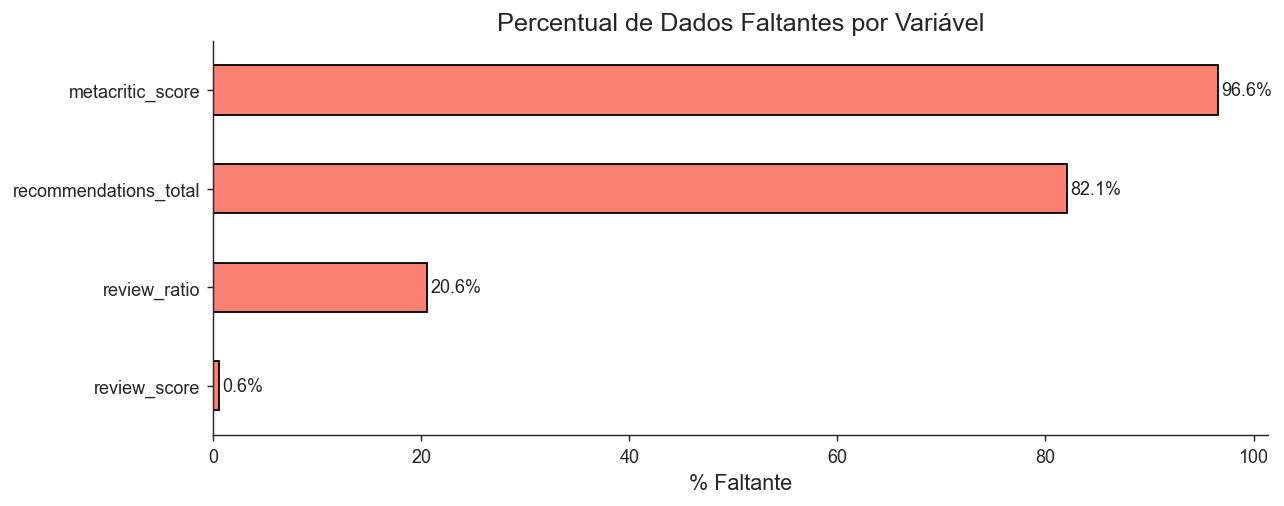

In [67]:
# Mapa de dados faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Faltantes": missing,
    "% do Total": missing_pct
}).sort_values("Faltantes", ascending=False)

# Exibir apenas colunas com algum dado faltante
missing_com_falha = missing_df[missing_df["Faltantes"] > 0]

if missing_com_falha.empty:
    print("✅ Nenhum dado faltante nas colunas do modelo.")
else:
    print(missing_com_falha.to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
missing_com_falha["% do Total"].plot(kind="barh", ax=ax, color="salmon", edgecolor="black")
ax.set_title("Percentual de Dados Faltantes por Variável")
ax.set_xlabel("% Faltante")
ax.invert_yaxis()
for i, v in enumerate(missing_com_falha["% do Total"]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("eda_v2_01_dados_faltantes.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


---
## Variável-Alvo: Popularidade (`reviews_total`)

Neste trabalho, pensando em variável alvo como 'reviews_total' o número total de avaliações de um jogo, que é utilizado como **proxy de popularidade**.
Me parece uma escolha  fundamentada no fato de que, na plataforma Steam, apenas usuários que adquiriram o jogo podem realizar avaliações (ainda tenho que pesquisar sobre aquela questão de multiplicar por 20 que você comentou professor), tornando esse indicador diretamente proporcional ao engajamento e à base de jogadores de cada título.

### Distribuição Bruta e Transformação Logarítmica

Me parece que distribuição da variável-alvo é caracterizada por uma **assimetria positiva extrema**:
poucos jogos concentram milhões de avaliações, enquanto a ampla maioria possui valores próximos de zero.
Para fins de modelagem e visualização, aplica-se a transformação **log(x + 1)**, que aproxima a distribuição de uma forma mais simétrica.


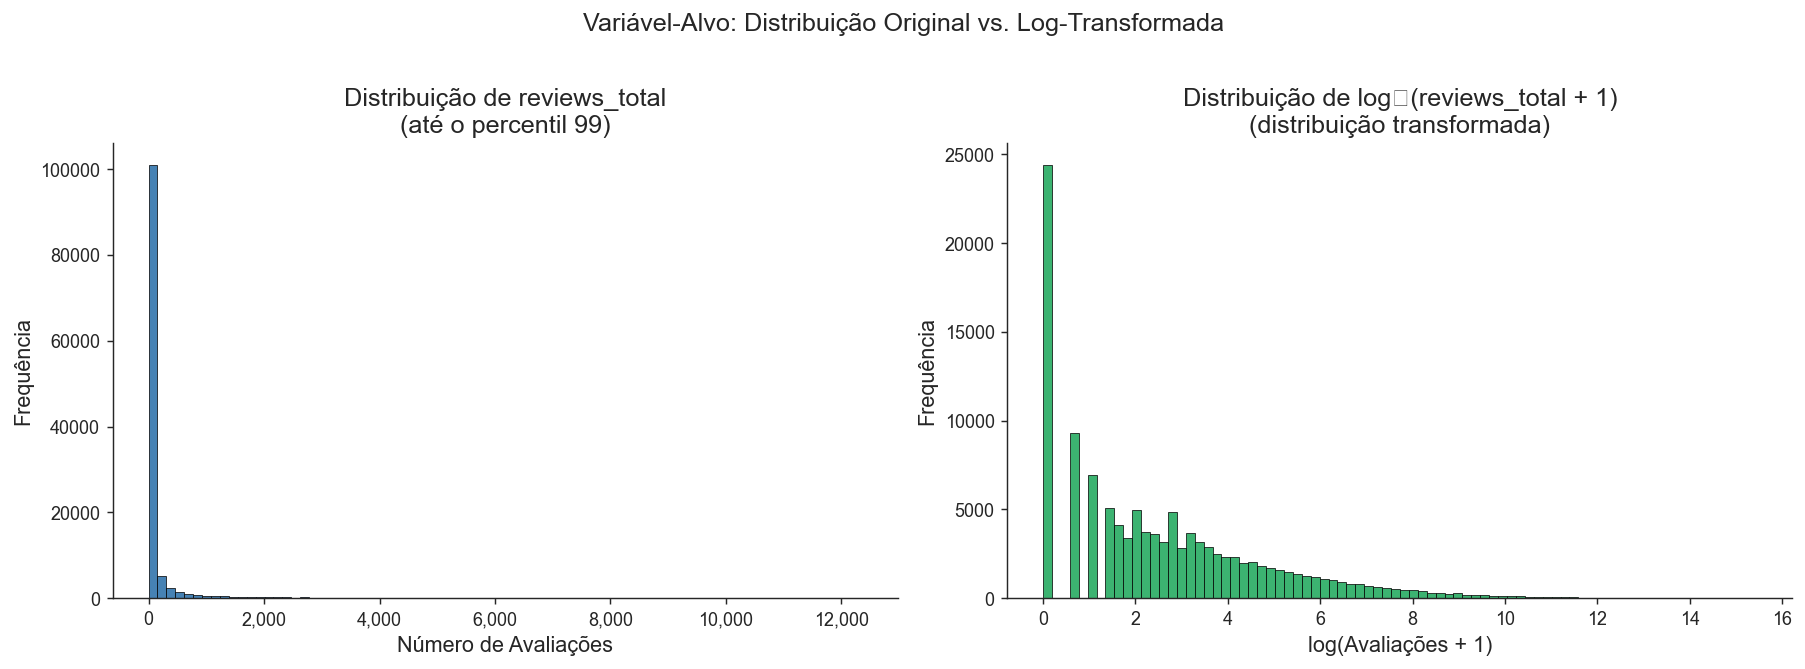

── Estatísticas Descritivas de reviews_total ──
count     118537.00
mean         927.08
std        20901.22
min            0.00
25%            1.00
50%            8.00
75%           48.00
max      5136950.00

Assimetria (skewness) : 143.87
Curtose               : 31763.24

Jogos com 0 avaliações: 24,420 (20.6%)


In [68]:
# Criar coluna transformada
df["log_reviews"] = np.log1p(df["reviews_total"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição original (até percentil 99 para legibilidade)
p99 = df["reviews_total"].quantile(0.99)
ax = axes[0]
ax.hist(df[df["reviews_total"] <= p99]["reviews_total"],
        bins=80, color="steelblue", edgecolor="black", linewidth=0.4)
ax.set_title("Distribuição de reviews_total\n(até o percentil 99)")
ax.set_xlabel("Número de Avaliações")
ax.set_ylabel("Frequência")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Distribuição log-transformada
ax = axes[1]
ax.hist(df["log_reviews"], bins=80, color="mediumseagreen",
        edgecolor="black", linewidth=0.4)
ax.set_title("Distribuição de log₁(reviews_total + 1)\n(distribuição transformada)")
ax.set_xlabel("log(Avaliações + 1)")
ax.set_ylabel("Frequência")

plt.suptitle("Variável-Alvo: Distribuição Original vs. Log-Transformada", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("eda_v2_02_distribuicao_alvo.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

# Estatísticas
print("── Estatísticas Descritivas de reviews_total ──")
print(df["reviews_total"].describe().round(2).to_string())
print(f"\nAssimetria (skewness) : {df['reviews_total'].skew():.2f}")
print(f"Curtose               : {df['reviews_total'].kurtosis():.2f}")
print(f"\nJogos com 0 avaliações: {(df['reviews_total'] == 0).sum():,} ({(df['reviews_total'] == 0).mean()*100:.1f}%)")


### Top 20 Jogos Mais Avaliados

Os jogos com maior número de avaliações são, em geral, títulos de grande apelo comercial e longevidade na plataforma.
Analisá-los permite compreender o "teto" da variável-alvo e identificar possíveis outliers.


In [54]:
top20 = df.nlargest(20, "reviews_total")[
    ["name", "reviews_total", "reviews_positive", "reviews_negative",
     "review_score_desc", "is_free", "price_brl", "release_year"]
].reset_index(drop=True)
top20.index += 1  # Ranking começa em 1

top20["reviews_total"] = top20["reviews_total"].apply(lambda x: f"{int(x):,}")
top20["reviews_positive"] = top20["reviews_positive"].apply(lambda x: f"{int(x):,}")
top20["reviews_negative"] = top20["reviews_negative"].apply(lambda x: f"{int(x):,}")
top20["price_brl"] = top20["price_brl"].apply(lambda x: "Grátis" if x == 0 else f"R$ {x:.2f}")
top20.columns = ["Nome", "Total", "Positivas", "Negativas", "Sentimento", "Grátis", "Preço", "Ano"]
top20


,Nome,Total,Positivas,Negativas,Sentimento,Grátis,Preço,Ano
1,Counter-Strike 2,"5,136,950","4,386,336","750,614",Very Positive,True,Grátis,2012.0
2,PUBG: BATTLEGROUNDS,"1,760,712","983,405","777,307",Mixed,True,Grátis,2017.0
3,Tom Clancy's Rainbow Six Siege,"1,244,793","1,031,293","213,500",Very Positive,True,Grátis,2015.0
4,Terraria,"1,219,087","1,189,224","29,863",Overwhelmingly Positive,False,R$ 32.99,2011.0
5,Rust,"1,145,371","999,410","145,961",Very Positive,False,R$ 119.99,2018.0
6,Garry's Mod,"1,073,628","1,041,027","32,601",Overwhelmingly Positive,False,R$ 9.99,2006.0
7,Black Myth: Wukong,"873,856","842,645","31,211",Overwhelmingly Positive,False,R$ 229.99,2024.0
8,Stardew Valley,"872,364","859,453","12,911",Overwhelmingly Positive,False,R$ 24.99,2016.0
9,Cyberpunk 2077,"850,482","740,580","109,902",Very Positive,False,R$ 59.99,2020.0
10,HELLDIVERS™ 2,"828,665","629,226","199,439",Mostly Positive,False,R$ 199.50,2024.0


### Categorização da Popularidade

Dado o comportamento da variável-alvo com mais de 52% dos jogos sem nenhuma avaliação e uma cauda extremamente longa eu a abordagem de **classificação multiclasse** como alternativa à regressão pura.
Os limiares propostos a seguir são baseados na distribuição empírica dos dados e na escala de avaliação da própria plataforma Steam.


── Distribuição por Classe de Popularidade ──
                     Jogos  % do Total
popularidade_classe                   
Sem Avaliações (0)   24420        20.6
Muito Baixa (1–9)    37473        31.6
Baixa (10–99)        35125        29.6
Moderada (100–999)   15054        12.7
Alta (1.000+)         6465         5.5


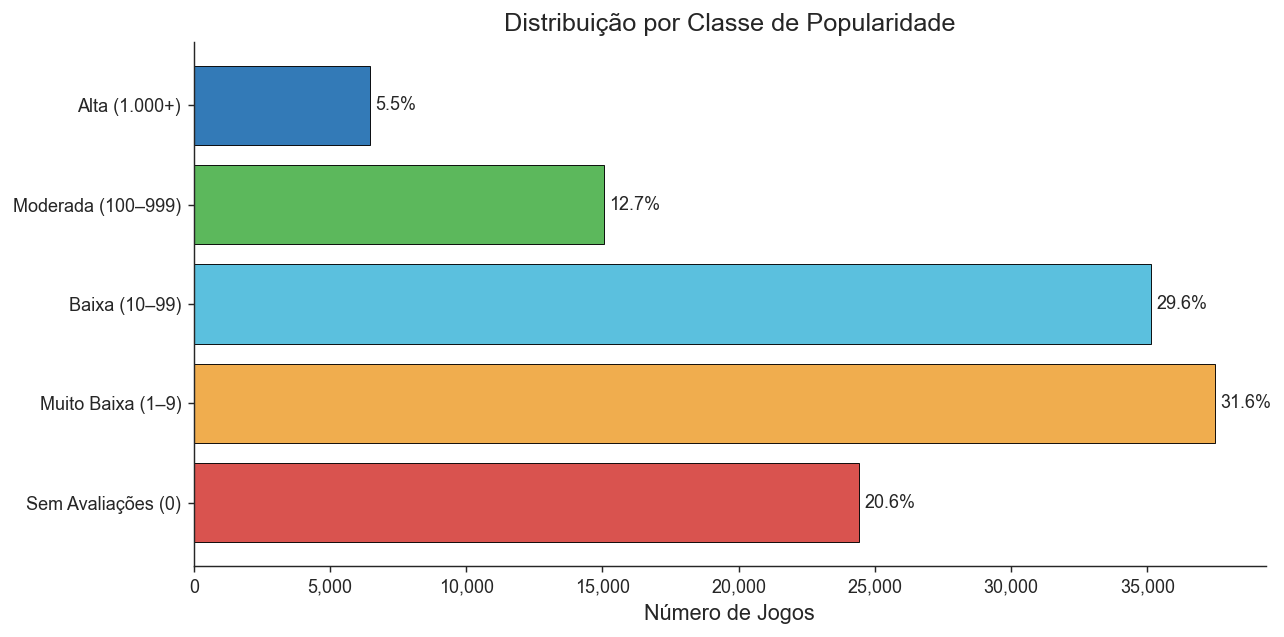

In [69]:
# Definir classes de popularidade
bins   = [-1, 0, 9, 99, 999, float("inf")]
labels = ["Sem Avaliações (0)",
          "Muito Baixa (1–9)",
          "Baixa (10–99)",
          "Moderada (100–999)",
          "Alta (1.000+)"]

df["popularidade_classe"] = pd.cut(df["reviews_total"], bins=bins, labels=labels)
contagem = df["popularidade_classe"].value_counts().reindex(labels)
pct      = (contagem / len(df) * 100).round(1)

resumo_classes = pd.DataFrame({"Jogos": contagem, "% do Total": pct})
print("── Distribuição por Classe de Popularidade ──")
print(resumo_classes.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
cores = ["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c", "#337ab7"]
bars = ax.barh(resumo_classes.index, resumo_classes["Jogos"],
               color=cores, edgecolor="black", linewidth=0.5)
for bar, pct_val in zip(bars, pct):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{pct_val:.1f}%", va="center", fontsize=10)
ax.set_title("Distribuição por Classe de Popularidade")
ax.set_xlabel("Número de Jogos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("eda_v2_03_classes_popularidade.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


---
## Análise Univariada das Variáveis Numéricas

Análise individual das variáveis numéricas do dataset para compreensão de suas distribuições,
identificação de outliers e avaliação de sua relevância como preditores de popularidade.


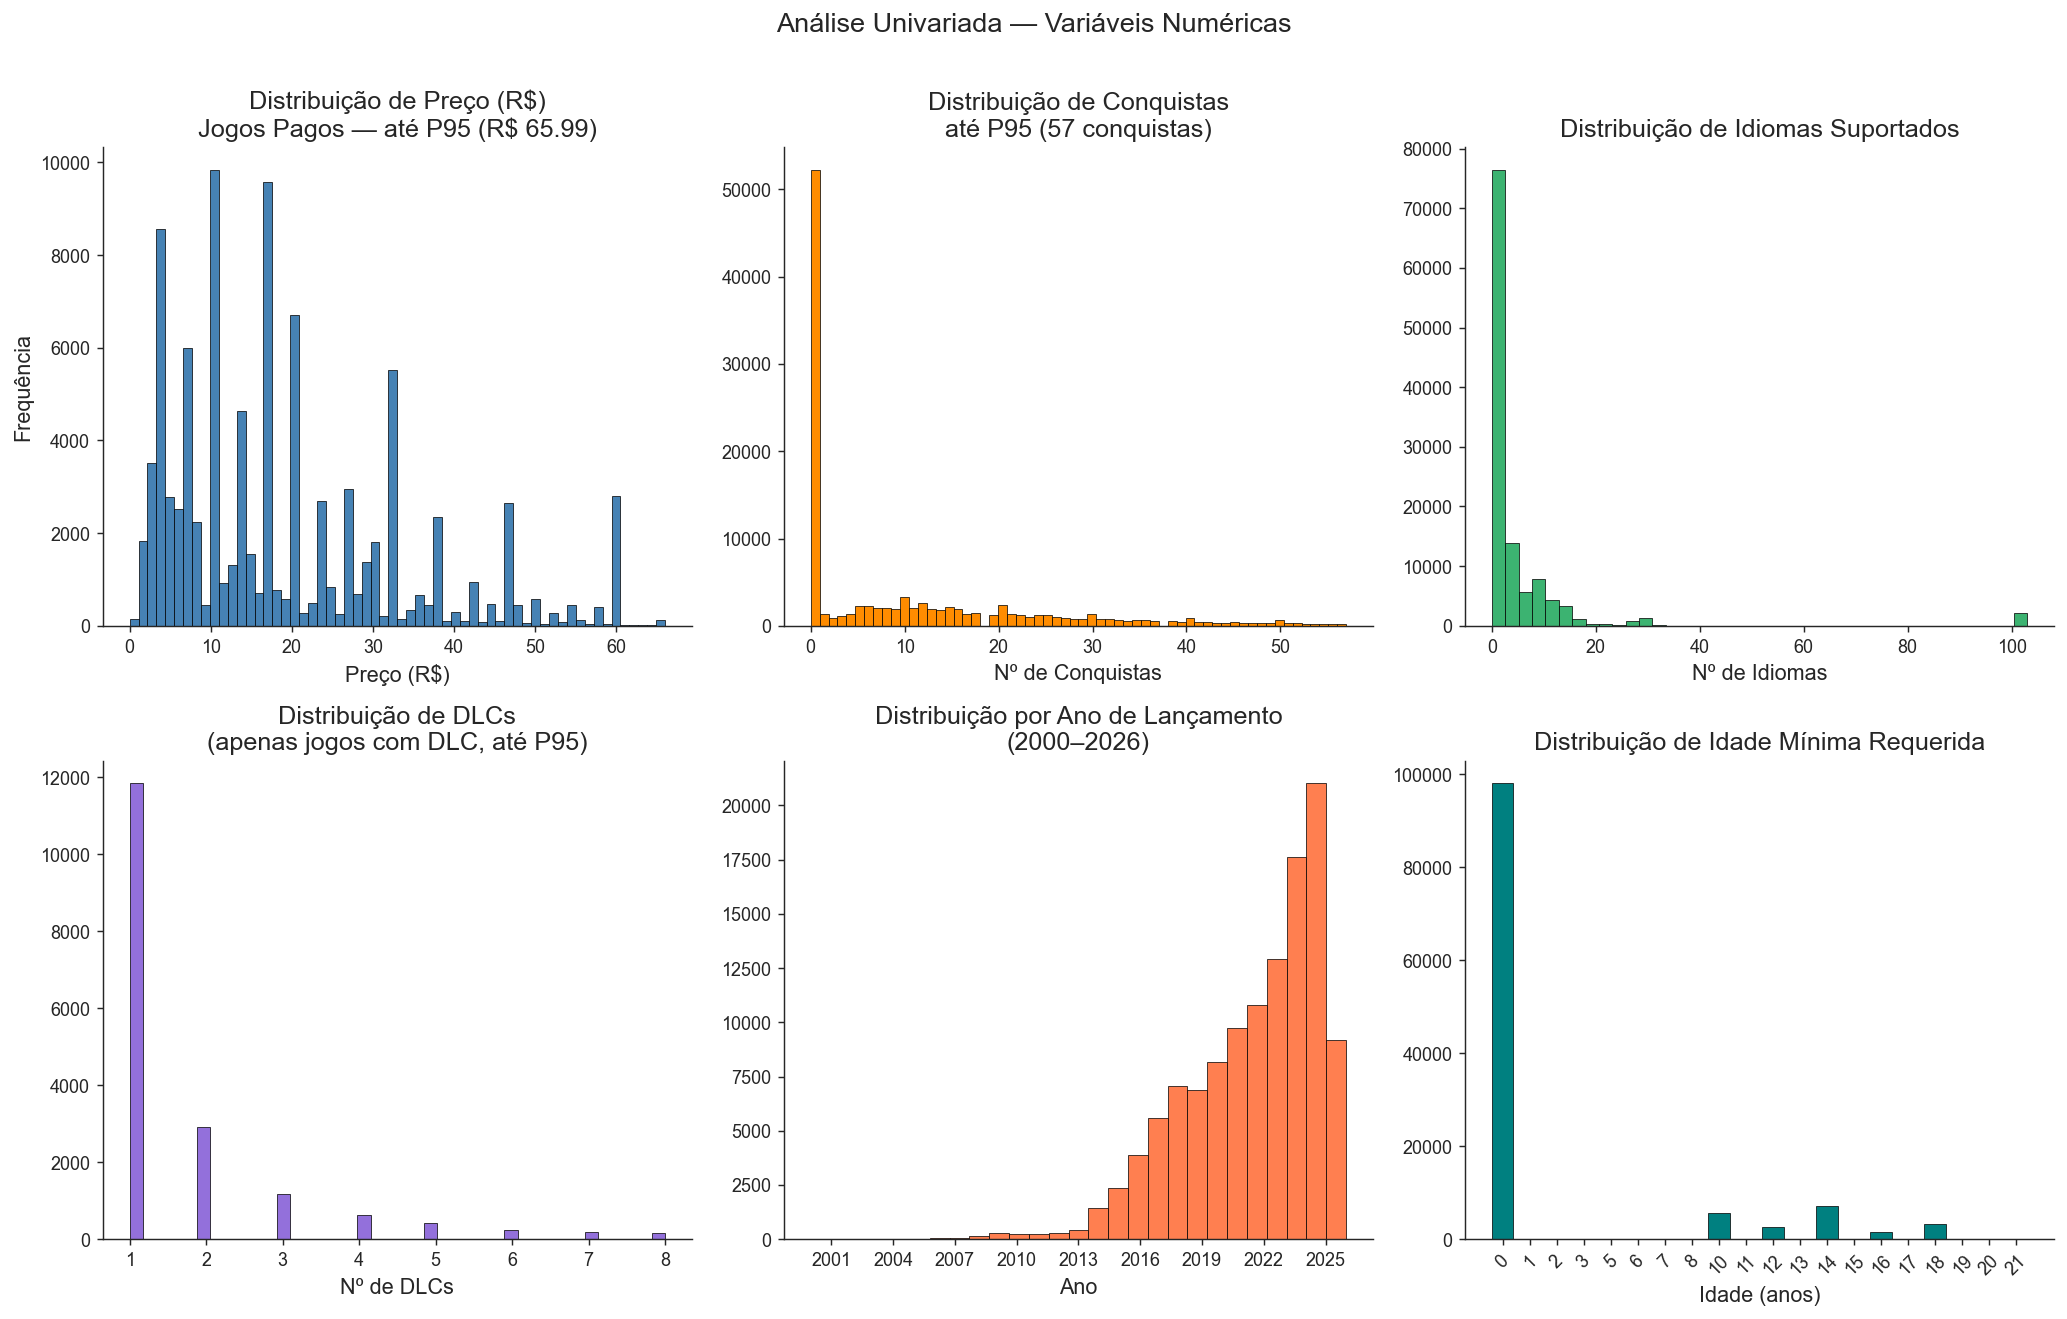

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Preço ──────────────────────────────────────────────────────────────────────
ax = axes[0, 0]
price_paid = df[df["is_free"] == False]["price_brl"].dropna()
p95 = price_paid.quantile(0.95)
ax.hist(price_paid[price_paid <= p95], bins=60, color="steelblue", edgecolor="black", lw=0.4)
ax.set_title(f"Distribuição de Preço (R$)\nJogos Pagos — até P95 (R$ {p95:.2f})")
ax.set_xlabel("Preço (R$)")
ax.set_ylabel("Frequência")

# ── Conquistas ─────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ach = df["achievements_total"].dropna()
p95_a = ach.quantile(0.95)
ax.hist(ach[ach <= p95_a], bins=60, color="darkorange", edgecolor="black", lw=0.4)
ax.set_title(f"Distribuição de Conquistas\naté P95 ({int(p95_a)} conquistas)")
ax.set_xlabel("Nº de Conquistas")

# ── Idiomas suportados ─────────────────────────────────────────────────────────
ax = axes[0, 2]
langs = df["supported_languages_count"].dropna()
ax.hist(langs, bins=40, color="mediumseagreen", edgecolor="black", lw=0.4)
ax.set_title("Distribuição de Idiomas Suportados")
ax.set_xlabel("Nº de Idiomas")

# ── DLCs ───────────────────────────────────────────────────────────────────────
ax = axes[1, 0]
dlc = df[df["dlc_count"] > 0]["dlc_count"]
p95_d = dlc.quantile(0.95)
ax.hist(dlc[dlc <= p95_d], bins=40, color="mediumpurple", edgecolor="black", lw=0.4)
ax.set_title("Distribuição de DLCs\n(apenas jogos com DLC, até P95)")
ax.set_xlabel("Nº de DLCs")

# ── Ano de lançamento ──────────────────────────────────────────────────────────
ax = axes[1, 1]
years = df["release_year"].dropna()
years = years[years.between(2000, 2026)]
ax.hist(years, bins=27, color="coral", edgecolor="black", lw=0.4)
ax.set_title("Distribuição por Ano de Lançamento\n(2000–2026)")
ax.set_xlabel("Ano")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Idade requerida ────────────────────────────────────────────────────────────
ax = axes[1, 2]
age = df["required_age"].value_counts().sort_index()
ax.bar(age.index.astype(str), age.values, color="teal", edgecolor="black", lw=0.4)
ax.set_title("Distribuição de Idade Mínima Requerida")
ax.set_xlabel("Idade (anos)")
ax.tick_params(axis="x", rotation=45)

plt.suptitle("Análise Univariada — Variáveis Numéricas", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("eda_v2_04_variaveis_numericas.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


---
## Análise de Gêneros

Os gêneros são variáveis binárias (one-hot encoded) que indicam se um jogo pertence a determinada categoria de gênero.
Um jogo pode pertencer a múltiplos gêneros simultaneamente.

### Frequência de Gêneros


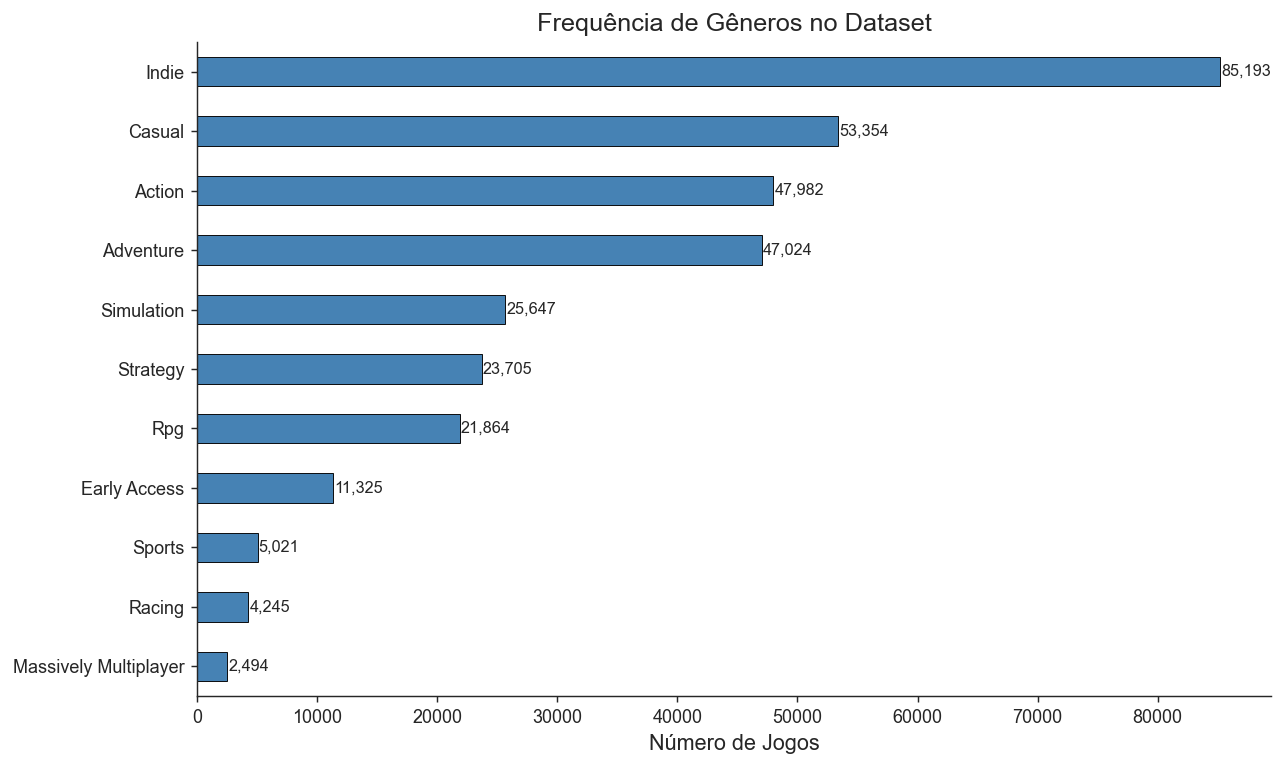

In [71]:
genre_cols = [c for c in df.columns if c.startswith("genre_")]
genre_counts = df[genre_cols].sum().sort_values(ascending=True)
genre_counts.index = (genre_counts.index
                      .str.replace("genre_", "")
                      .str.replace("_", " ")
                      .str.title())

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black", lw=0.5)
ax.set_title("Frequência de Gêneros no Dataset")
ax.set_xlabel("Número de Jogos")
for i, v in enumerate(genre_counts):
    ax.text(v + 100, i, f"{int(v):,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_v2_05_generos_frequencia.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


### Popularidade Média por Gênero

Analisamos a média da variável log-transformada das avaliações por gênero.
A transformação logarítmica é necessária para mitigar o efeito distorcivo dos outliers
(títulos com milhões de avaliações) sobre a média.


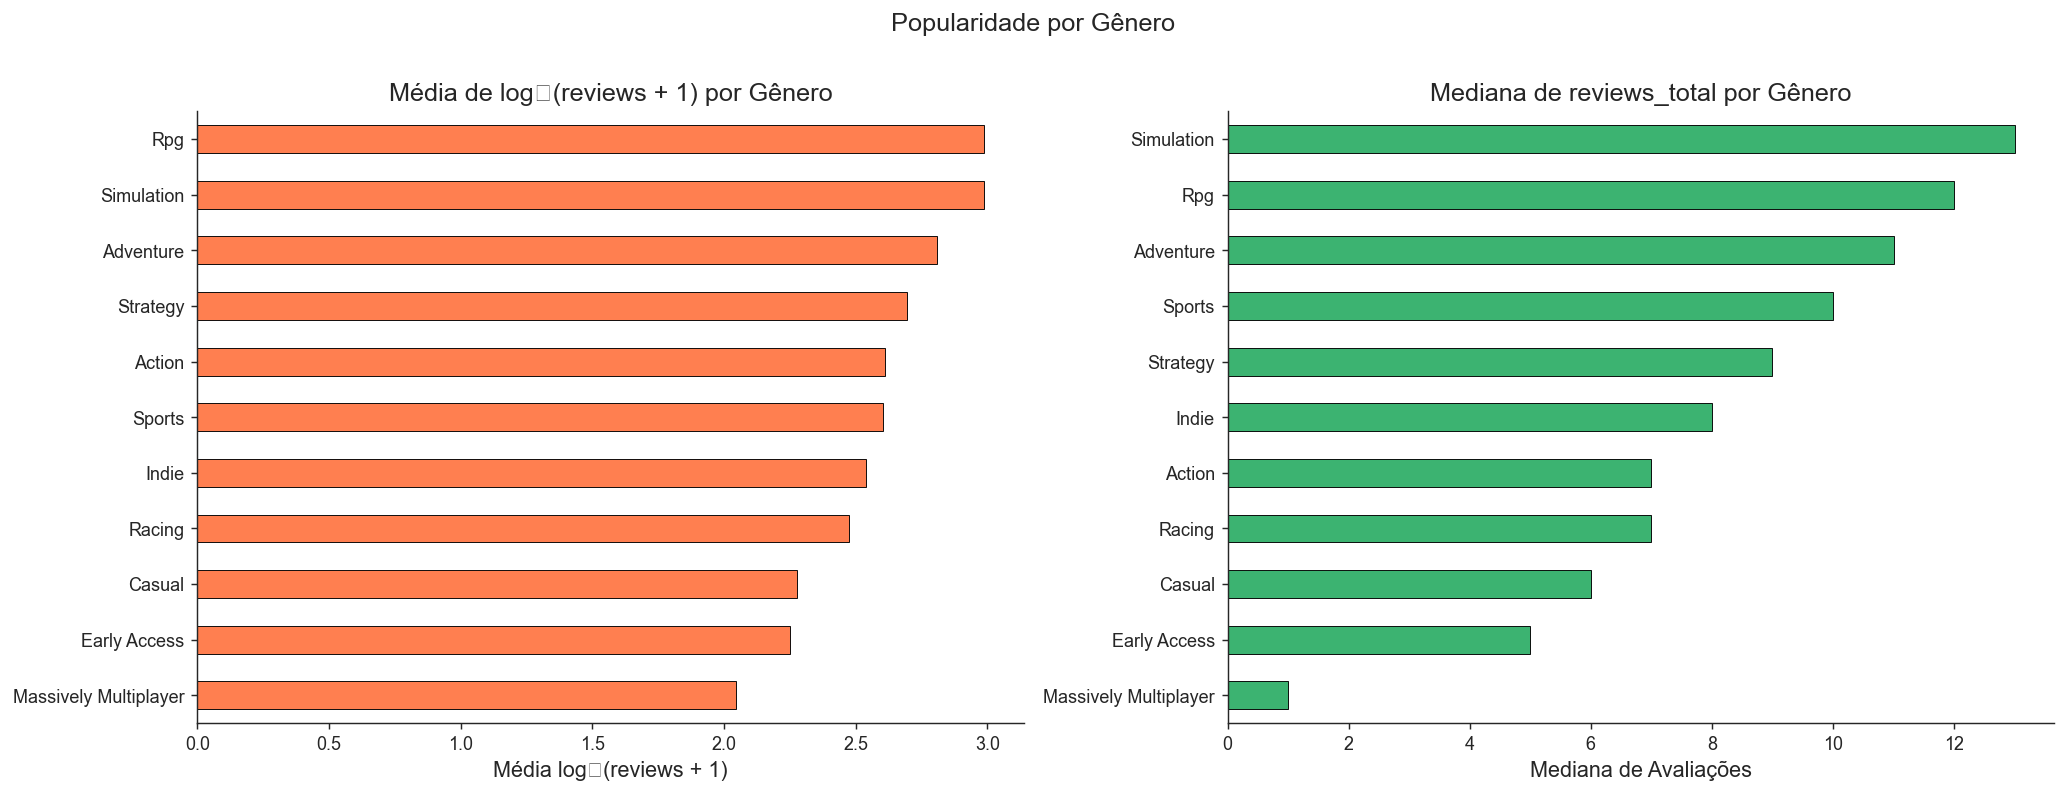

In [72]:
genre_log_means = {}
genre_med_total  = {}

for col in genre_cols:
    name = col.replace("genre_", "").replace("_", " ").title()
    subset = df[df[col] == 1]
    genre_log_means[name] = subset["log_reviews"].mean()
    genre_med_total[name] = subset["reviews_total"].median()

mean_series = pd.Series(genre_log_means).sort_values()
med_series  = pd.Series(genre_med_total).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Média log-reviews
ax = axes[0]
mean_series.plot(kind="barh", ax=ax, color="coral", edgecolor="black", lw=0.5)
ax.set_title("Média de log₁(reviews + 1) por Gênero")
ax.set_xlabel("Média log₁(reviews + 1)")

# Mediana reviews_total
ax = axes[1]
med_series.plot(kind="barh", ax=ax, color="mediumseagreen", edgecolor="black", lw=0.5)
ax.set_title("Mediana de reviews_total por Gênero")
ax.set_xlabel("Mediana de Avaliações")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Popularidade por Gênero", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_v2_06_generos_popularidade.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


---
## Análise de Categorias e Características de Jogabilidade

Além dos gêneros, a Steam classifica jogos segundo **categorias de jogabilidade**, como suporte a multijogador,
cooperativo, conquistas e controlador. Essas características descrevem a experiência oferecida pelo jogo e
são potencialmente relevantes como preditores de popularidade.


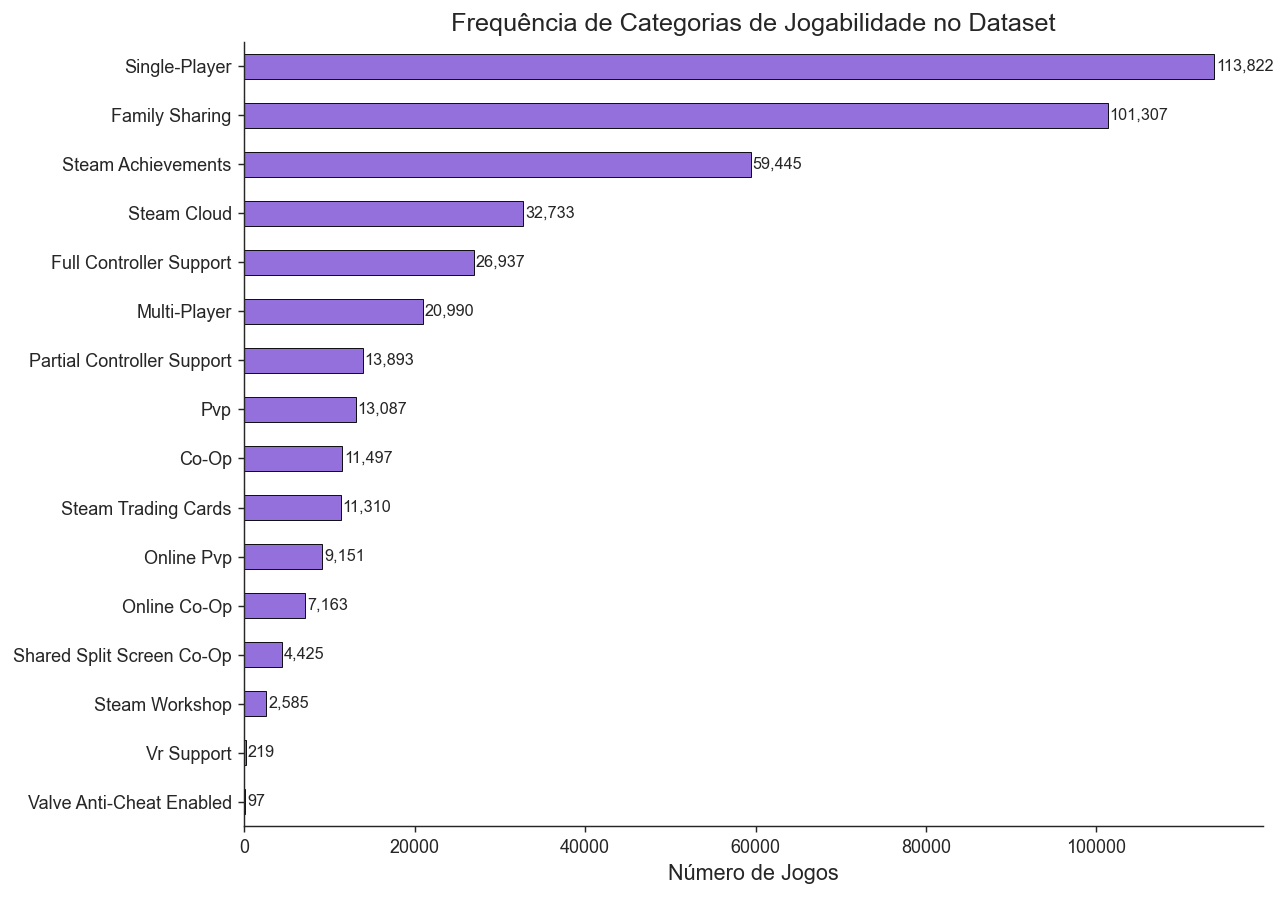

In [73]:
cat_cols = [c for c in df.columns if c.startswith("cat_")]
cat_counts = df[cat_cols].sum().sort_values(ascending=True)
cat_counts.index = (cat_counts.index
                    .str.replace("cat_", "")
                    .str.replace("_", " ")
                    .str.title())

fig, ax = plt.subplots(figsize=(10, 7))
cat_counts.plot(kind="barh", ax=ax, color="mediumpurple", edgecolor="black", lw=0.5)
ax.set_title("Frequência de Categorias de Jogabilidade no Dataset")
ax.set_xlabel("Número de Jogos")
for i, v in enumerate(cat_counts):
    ax.text(v + 200, i, f"{int(v):,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_v2_07_categorias_frequencia.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


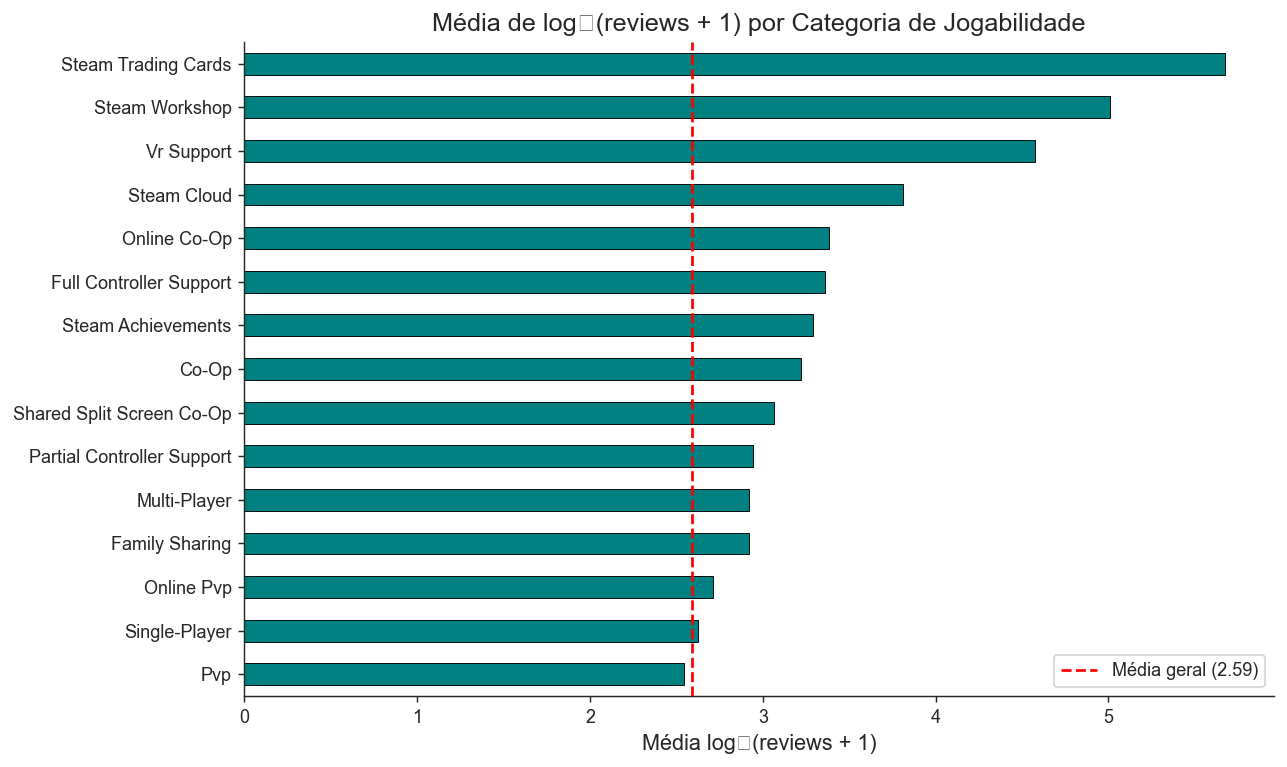

In [74]:
# Impacto das categorias na popularidade (log_reviews médio)
cat_log_means = {}
for col in cat_cols:
    name = col.replace("cat_", "").replace("_", " ").title()
    subset = df[df[col] == 1]
    if len(subset) > 100:  # Filtro mínimo de representatividade
        cat_log_means[name] = subset["log_reviews"].mean()

cat_mean_series = pd.Series(cat_log_means).sort_values()

# Média geral como linha de referência
media_geral = df["log_reviews"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = cat_mean_series.plot(kind="barh", ax=ax, color="teal", edgecolor="black", lw=0.5)
ax.axvline(media_geral, color="red", linestyle="--", linewidth=1.5, label=f"Média geral ({media_geral:.2f})")
ax.set_title("Média de log₁(reviews + 1) por Categoria de Jogabilidade")
ax.set_xlabel("Média log₁(reviews + 1)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_v2_08_categorias_popularidade.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


---
## Análise de Plataformas

A Steam é uma plataforma multiplataforma, suportando Windows, macOS e Linux.
Analisamos a prevalência de suporte por sistema operacional e seu eventual impacto na popularidade.


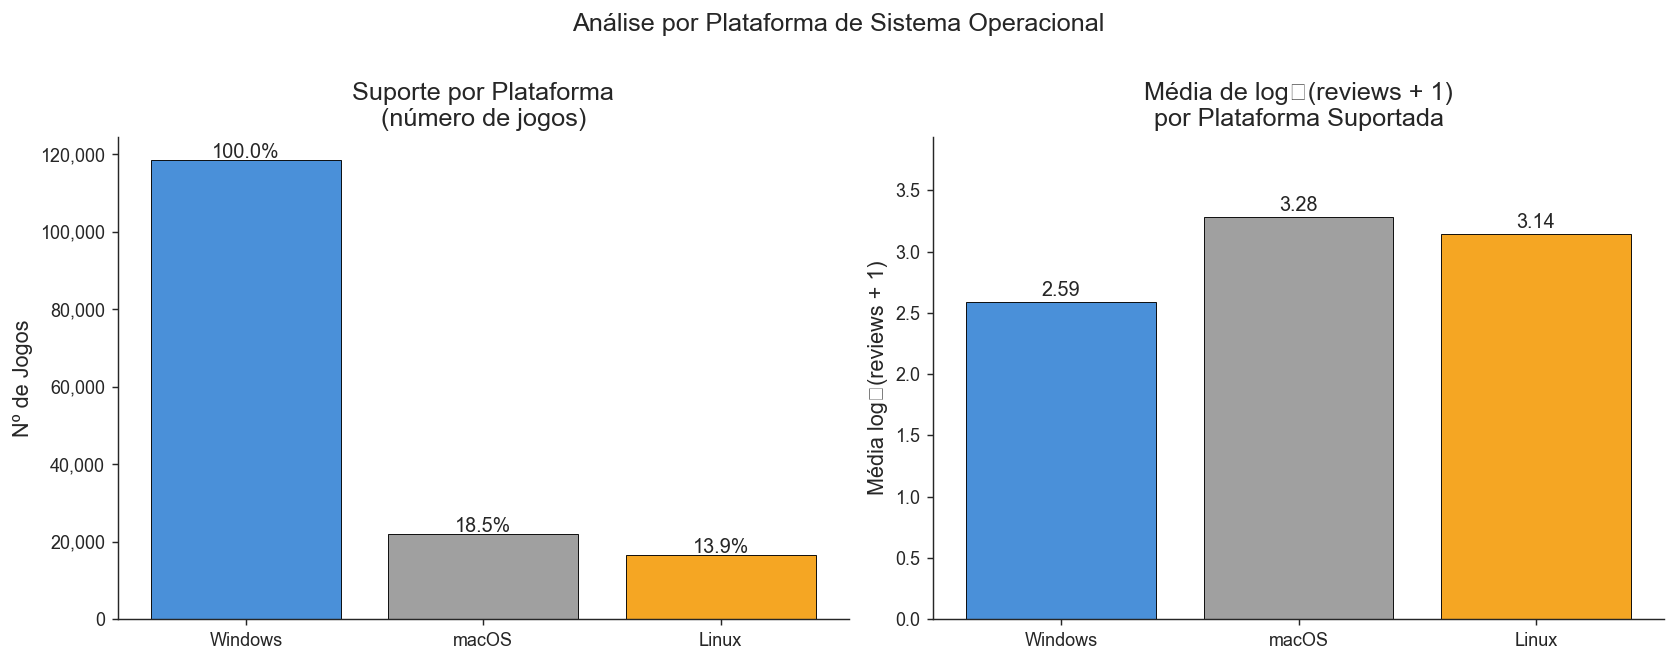

In [75]:
plat_data = {
    "Windows": df["windows"].sum(),
    "macOS":   df["mac"].sum(),
    "Linux":   df["linux"].sum(),
}

plat_log = {
    "Windows": df[df["windows"] == 1]["log_reviews"].mean(),
    "macOS":   df[df["mac"]     == 1]["log_reviews"].mean(),
    "Linux":   df[df["linux"]   == 1]["log_reviews"].mean(),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Frequência
ax = axes[0]
ax.bar(plat_data.keys(), plat_data.values(),
       color=["#4A90D9", "#A0A0A0", "#F5A623"], edgecolor="black", lw=0.5)
ax.set_title("Suporte por Plataforma\n(número de jogos)")
ax.set_ylabel("Nº de Jogos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (k, v) in enumerate(plat_data.items()):
    pct = v / len(df) * 100
    ax.text(i, v + 500, f"{pct:.1f}%", ha="center", fontsize=11)

# Popularidade
ax = axes[1]
ax.bar(plat_log.keys(), plat_log.values(),
       color=["#4A90D9", "#A0A0A0", "#F5A623"], edgecolor="black", lw=0.5)
ax.set_title("Média de log₁(reviews + 1)\npor Plataforma Suportada")
ax.set_ylabel("Média log₁(reviews + 1)")
ax.set_ylim(0, max(plat_log.values()) * 1.2)
for i, (k, v) in enumerate(plat_log.items()):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=11)

plt.suptitle("Análise por Plataforma de Sistema Operacional", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_v2_09_plataformas.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


---
## Análise Temporal




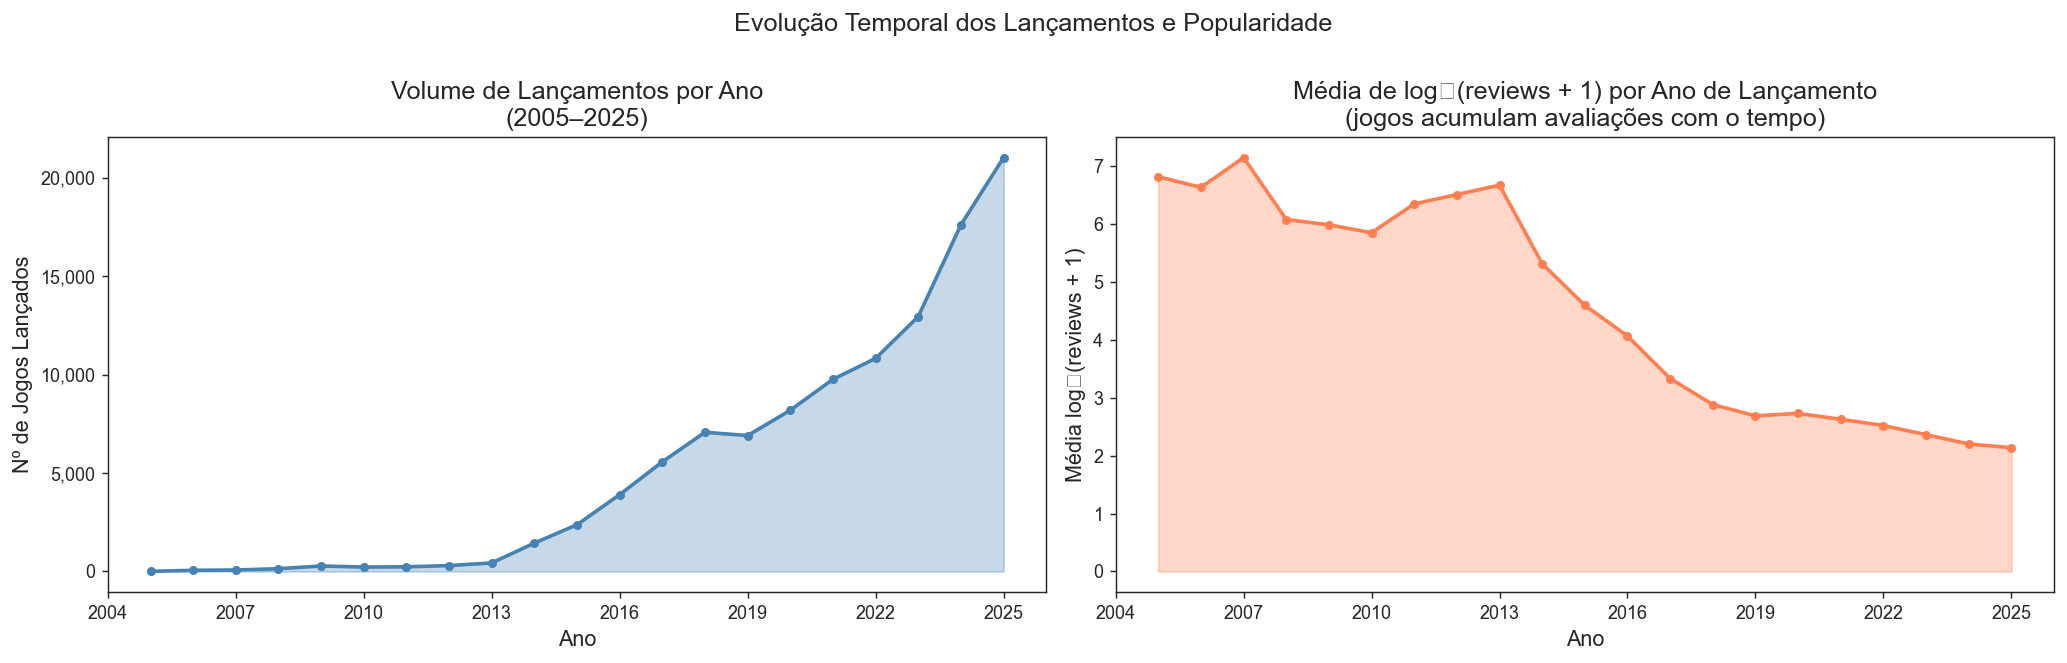

── Top 10 Anos com Mais Lançamentos ──
release_year
2025.0    21015
2024.0    17602
2023.0    12940
2022.0    10820
2021.0     9758
2020.0     8186
2018.0     7069
2019.0     6899
2017.0     5567
2016.0     3902


In [62]:
df_years = df[df["release_year"].between(2005, 2025)].copy()
year_counts = df_years["release_year"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume de lançamentos por ano
ax = axes[0]
ax.fill_between(year_counts.index, year_counts.values, alpha=0.3, color="steelblue")
ax.plot(year_counts.index, year_counts.values, color="steelblue", linewidth=2, marker="o", markersize=4)
ax.set_title("Volume de Lançamentos por Ano\n(2005–2025)")
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de Jogos Lançados")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Popularidade média por ano de lançamento
year_log = df_years.groupby("release_year")["log_reviews"].mean()
ax = axes[1]
ax.fill_between(year_log.index, year_log.values, alpha=0.3, color="coral")
ax.plot(year_log.index, year_log.values, color="coral", linewidth=2, marker="o", markersize=4)
ax.set_title("Média de log₁(reviews + 1) por Ano de Lançamento\n(jogos acumulam avaliações com o tempo)")
ax.set_xlabel("Ano")
ax.set_ylabel("Média log₁(reviews + 1)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("Evolução Temporal dos Lançamentos e Popularidade", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_v2_10_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabela top anos
print("── Top 10 Anos com Mais Lançamentos ──")
print(year_counts.sort_values(ascending=False).head(10).to_string())


---
## Análise de Sentimento do Público (`review_score_desc`)

A variável `review_score_desc` representa a classificação oficial da Steam baseada na proporção
entre avaliações positivas e negativas. Esta variável é uma possível alternativa para a variável-alvo
em uma abordagem de **classificação multiclasse**, oferecendo uma escala ordinal de sentimento do público.


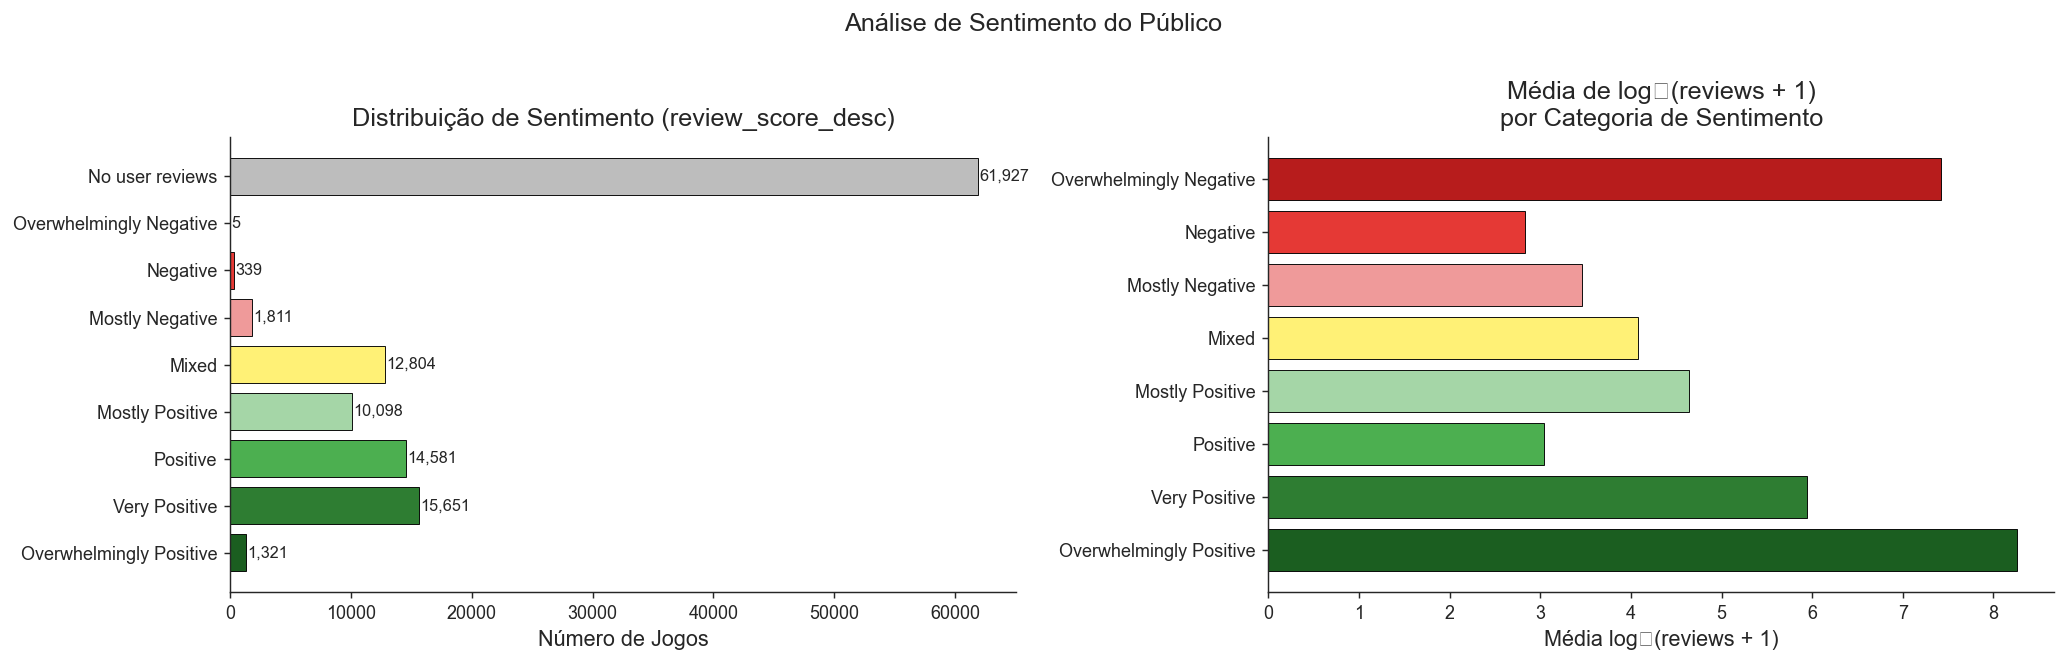

In [76]:
order = ["No user reviews", "Overwhelmingly Negative", "Negative",
         "Mostly Negative", "Mixed", "Mostly Positive",
         "Positive", "Very Positive", "Overwhelmingly Positive"]

score_counts = df["review_score_desc"].value_counts().reindex(order).dropna()

cores_sentimento = {
    "No user reviews"         : "#BDBDBD",
    "Overwhelmingly Negative" : "#B71C1C",
    "Negative"                : "#E53935",
    "Mostly Negative"         : "#EF9A9A",
    "Mixed"                   : "#FFF176",
    "Mostly Positive"         : "#A5D6A7",
    "Positive"                : "#4CAF50",
    "Very Positive"           : "#2E7D32",
    "Overwhelmingly Positive" : "#1B5E20",
}
cores_lista = [cores_sentimento[k] for k in score_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Frequência
ax = axes[0]
bars = ax.barh(score_counts.index, score_counts.values,
               color=cores_lista, edgecolor="black", lw=0.5)
ax.set_title("Distribuição de Sentimento (review_score_desc)")
ax.set_xlabel("Número de Jogos")
ax.invert_yaxis()
for bar in bars:
    w = bar.get_width()
    ax.text(w + 100, bar.get_y() + bar.get_height()/2,
            f"{int(w):,}", va="center", fontsize=9)

# Popularidade média por sentimento
subset_com_reviews = df[df["review_score_desc"] != "No user reviews"]
score_log = (subset_com_reviews
             .groupby("review_score_desc")["log_reviews"]
             .mean()
             .reindex([s for s in order if s != "No user reviews"])
             .dropna())
cores_lista2 = [cores_sentimento[k] for k in score_log.index]

ax = axes[1]
ax.barh(score_log.index, score_log.values,
        color=cores_lista2, edgecolor="black", lw=0.5)
ax.set_title("Média de log₁(reviews + 1)\npor Categoria de Sentimento")
ax.set_xlabel("Média log₁(reviews + 1)")
ax.invert_yaxis()

plt.suptitle("Análise de Sentimento do Público", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_v2_11_sentimento.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()


── Estatísticas do Índice de Aprovação (review_ratio) ──
  Jogos com pelo menos 1 avaliação: 94,117
count    94117.000
mean         0.758
std          0.259
min          0.000
25%          0.647
50%          0.833
75%          0.972
max          1.000


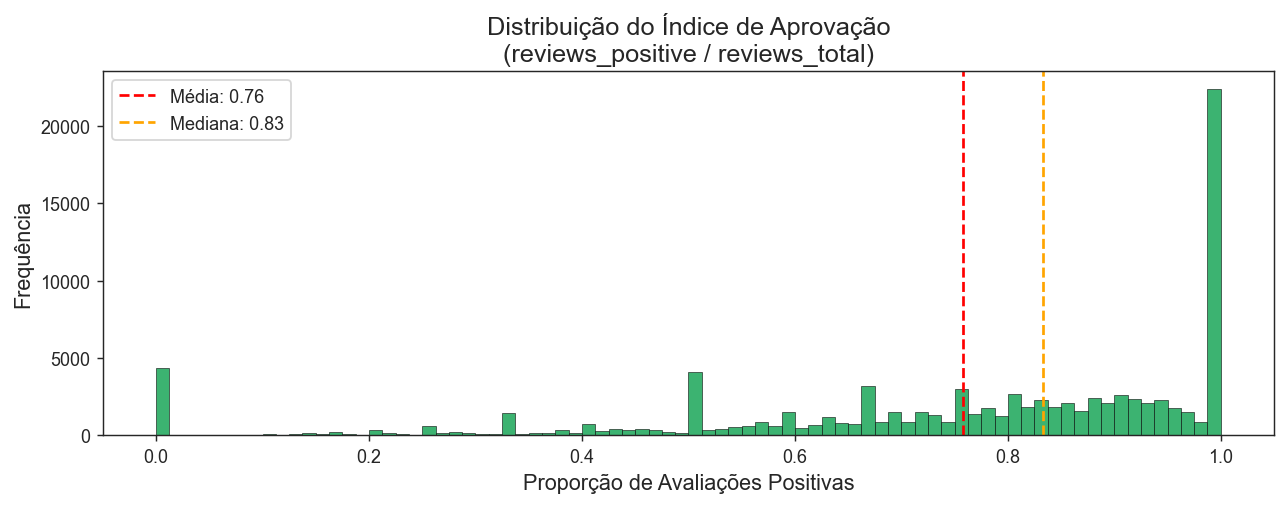

In [64]:
# Análise da taxa de avaliações positivas (review_ratio)
df_com_rev = df[df["reviews_total"] > 0].copy()
df_com_rev["review_ratio"] = df_com_rev["reviews_positive"] / df_com_rev["reviews_total"]

print("── Estatísticas do Índice de Aprovação (review_ratio) ──")
print(f"  Jogos com pelo menos 1 avaliação: {len(df_com_rev):,}")
print(df_com_rev["review_ratio"].describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_com_rev["review_ratio"], bins=80, color="mediumseagreen", edgecolor="black", lw=0.3)
ax.axvline(df_com_rev["review_ratio"].mean(), color="red", linestyle="--",
           label=f"Média: {df_com_rev['review_ratio'].mean():.2f}")
ax.axvline(df_com_rev["review_ratio"].median(), color="orange", linestyle="--",
           label=f"Mediana: {df_com_rev['review_ratio'].median():.2f}")
ax.set_title("Distribuição do Índice de Aprovação\n(reviews_positive / reviews_total)")
ax.set_xlabel("Proporção de Avaliações Positivas")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.savefig("eda_v2_12_review_ratio.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 11. Análise de Correlações

A análise de correlação de Pearson é utilizada para quantificar a associação linear entre cada variável preditora
e a variável-alvo log-transformada (`log_reviews`). Por trabalharmos com a versão logarítmica,
mitigamos o efeito distorcivo dos outliers e obtemos estimativas de correlação mais representativas.

> **Nota metodológica:** a correlação de Pearson captura apenas relações lineares. Associações não-lineares,
> que são comuns neste tipo de dado, serão exploradas pela própria rede neural durante o treinamento.


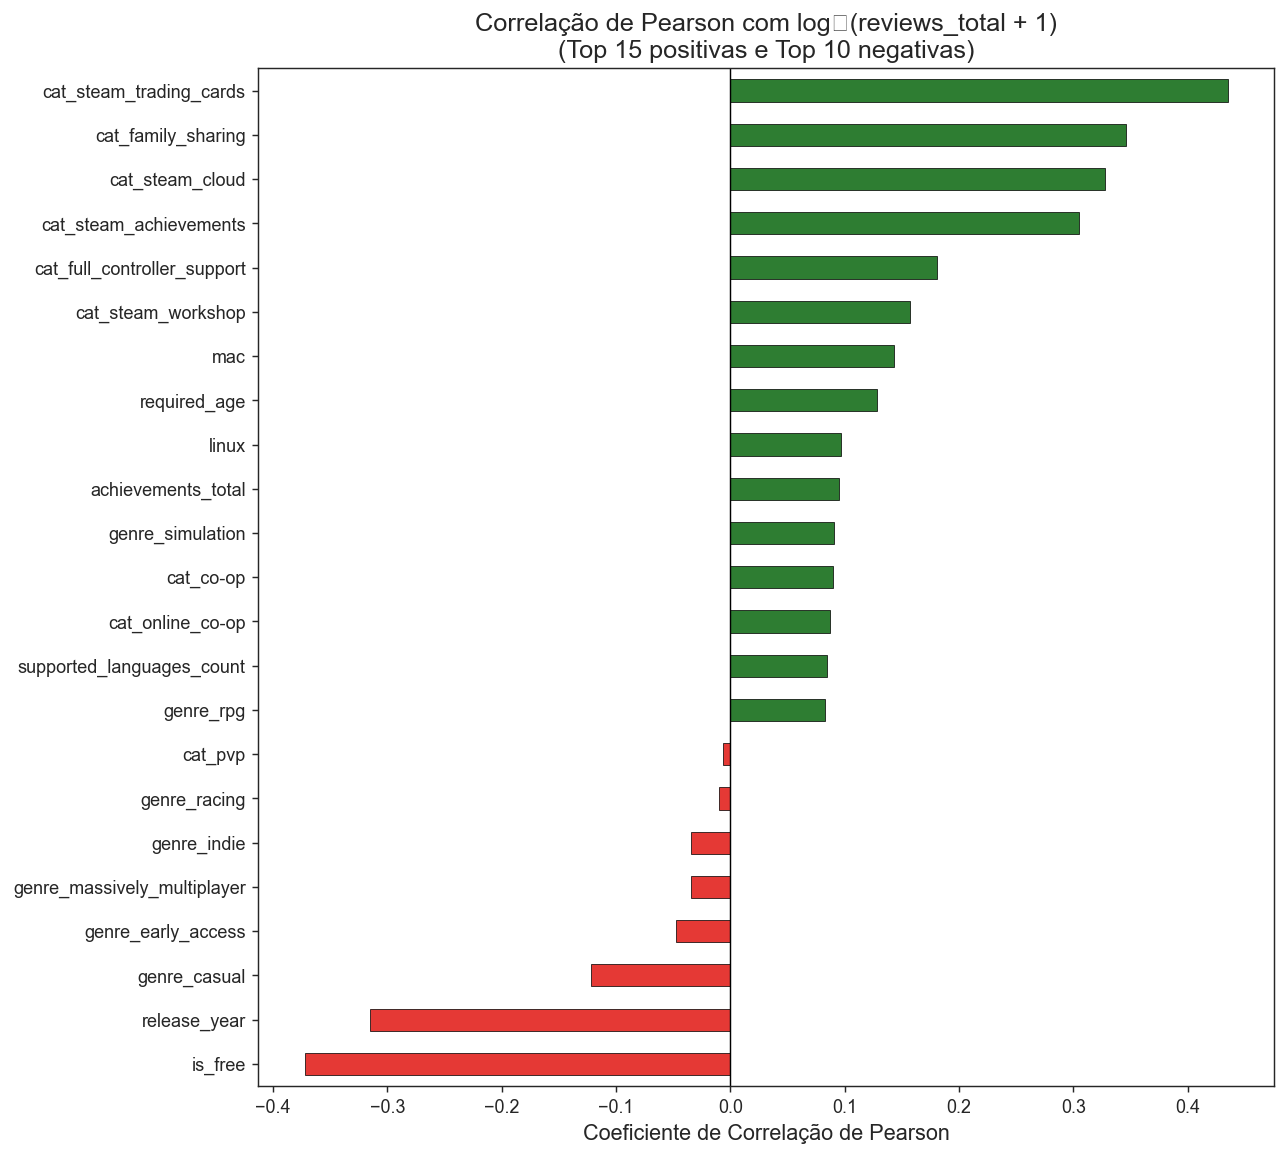

── Correlação completa com log_reviews ──
cat_steam_trading_cards           0.4351
cat_family_sharing                0.3456
cat_steam_cloud                   0.3279
cat_steam_achievements            0.3053
cat_full_controller_support       0.1810
cat_steam_workshop                0.1570
mac                               0.1428
required_age                      0.1284
linux                             0.0964
achievements_total                0.0954
genre_simulation                  0.0904
cat_co-op                         0.0902
cat_online_co-op                  0.0872
supported_languages_count         0.0847
genre_rpg                         0.0824
cat_valve_anti-cheat_enabled      0.0785
genre_adventure                   0.0771
cat_single-player                 0.0740
cat_multi-player                  0.0668
cat_partial_controller_support    0.0560
dlc_count                         0.0533
cat_shared_split_screen_co-op     0.0409
cat_vr_support                    0.0371
genre_strategy 

In [65]:
# Selecionar variáveis para a matriz de correlação
bool_and_bin_cols = (
    ["is_free", "windows", "mac", "linux"]
    + genre_cols
    + cat_cols
)

corr_df = df[["log_reviews", "price_brl", "achievements_total",
              "release_year", "supported_languages_count",
              "dlc_count", "required_age"] + bool_and_bin_cols].copy()

# Converter booleanos para inteiro
for col in corr_df.select_dtypes(include="bool").columns:
    corr_df[col] = corr_df[col].astype(int)

# Correlação com a variável-alvo
corr_target = (corr_df.corr()["log_reviews"]
               .drop("log_reviews")
               .sort_values(ascending=False))

# Barplot — Top correlações positivas e negativas
top_pos = corr_target[corr_target > 0].head(15)
top_neg = corr_target[corr_target < 0].tail(10)
corr_plot = pd.concat([top_pos, top_neg]).sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors = ["#E53935" if v < 0 else "#2E7D32" for v in corr_plot.values]
corr_plot.plot(kind="barh", ax=ax, color=colors, edgecolor="black", lw=0.4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação de Pearson com log₁(reviews_total + 1)\n(Top 15 positivas e Top 10 negativas)")
ax.set_xlabel("Coeficiente de Correlação de Pearson")
plt.tight_layout()
plt.savefig("eda_v2_13_correlacao_target.png", dpi=150, bbox_inches="tight")
plt.show()

print("── Correlação completa com log_reviews ──")
print(corr_target.round(4).to_string())


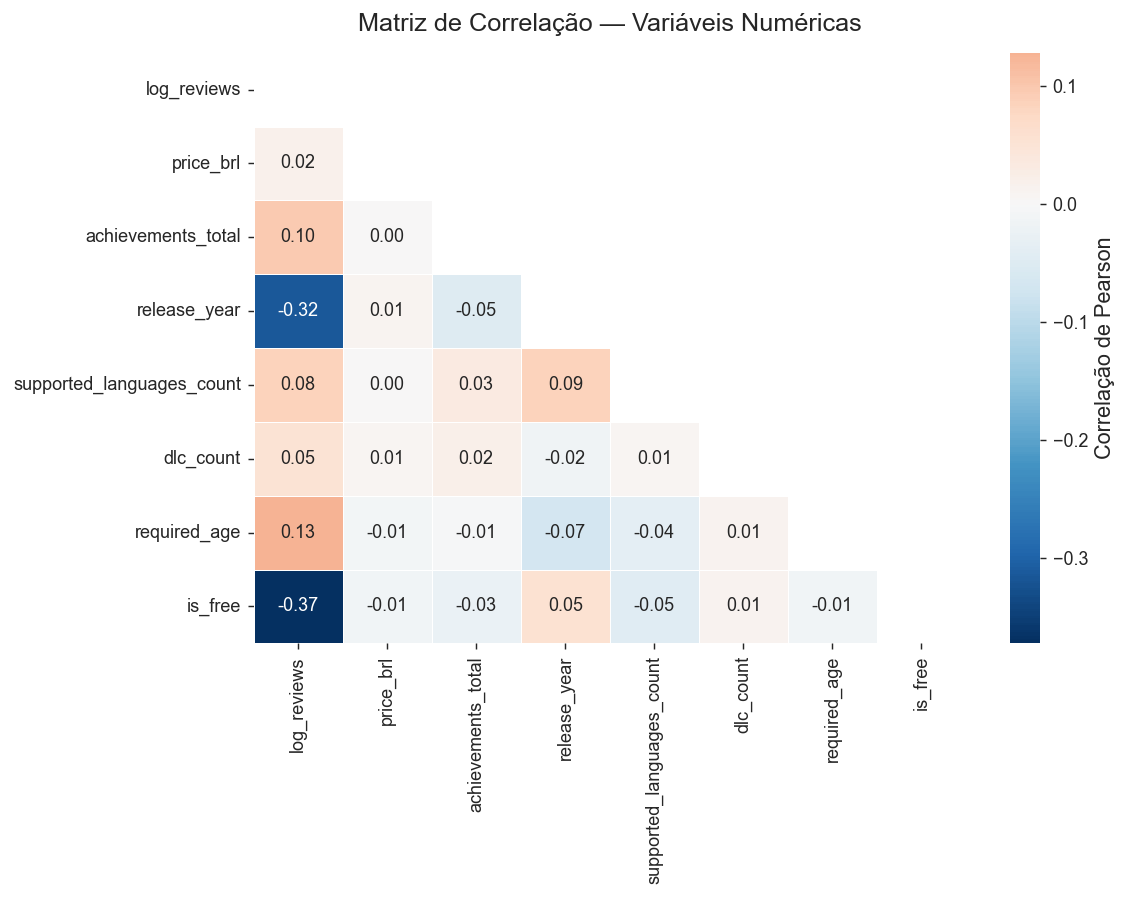

In [66]:
# Heatmap das variáveis numéricas entre si
num_cols_hm = ["log_reviews", "price_brl", "achievements_total",
               "release_year", "supported_languages_count", "dlc_count",
               "required_age", "is_free"]

corr_hm = df[num_cols_hm].copy()
corr_hm["is_free"] = corr_hm["is_free"].astype(int)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_hm.corr(), dtype=bool))
sns.heatmap(corr_hm.corr(), mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "Correlação de Pearson"})
ax.set_title("Matriz de Correlação — Variáveis Numéricas", pad=12)
plt.tight_layout()
plt.savefig("eda_v2_14_heatmap_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 12. Síntese e Recomendações para a Modelagem

### 12.1 Principais Achados

| Aspecto | Observação |
|---|---|
| **Escala da variável-alvo** | Distribuição com assimetria extrema; transformação `log1p` é obrigatória para regressão |
| **Concentração em zero** | ~20,6% dos jogos não possuem avaliações; a maioria dos jogos (75%) possui ≤ 48 avaliações |
| **Gênero predominante** | Indie representa ~72% do dataset, seguido por Casual (~45%) e Action (~40%) |
| **Categoria predominante** | Single-player está presente em ~96% dos jogos |
| **Crescimento exponencial** | Volume de lançamentos cresceu exponencialmente após 2012 com a abertura do Steam Direct |
| **Viés temporal** | Jogos mais antigos acumulam naturalmente mais avaliações; o ano de lançamento é um confundidor relevante |
| **Índice de aprovação** | A mediana do `review_ratio` está acima de 0.80, indicando que a maioria dos jogos com avaliações é bem recebida |

### 12.2 Decisões de Pré-Processamento Recomendadas

```
1. Variável-alvo:
   - Regressão → usar log1p(reviews_total) como target; reverter com expm1 nas previsões
   - Classificação → usar review_score_desc (9 classes) ou popularidade_classe (5 classes)

2. Normalização:
   - Variáveis numéricas contínuas (price_brl, achievements_total, etc.) → StandardScaler ou MinMaxScaler
   - Variáveis binárias (gêneros, categorias, plataformas, is_free) → já estão em {0, 1}, não normalizar

3. Variáveis a excluir do modelo:
   - metacritic_score (96.6% ausente — incluir geraria viés de seleção severo)
   - appid, name (identificadores sem poder preditivo)
   - reviews_positive, reviews_negative (derivadas de reviews_total — data leakage)
   - review_ratio (derivada de reviews_positive/reviews_total — data leakage)
   - log_reviews (derivada da target)

4. Engenharia de features sugerida:
   - Idade do jogo em anos (ano atual - release_year) → captura efeito de acúmulo temporal
   - Interação is_free × genre_massively_multiplayer → jogos MMO gratuitos têm comportamento distinto
```

### 12.3 Próximos Passos

1. **Coleta de Tags de Jogadores** via SteamSpy (`api-atomica-v3.py`) — enriquece o dataset com descritores semânticos dos jogos
2. **Definição da arquitetura da rede neural** — MLP (Multilayer Perceptron) como baseline, com possível uso de embeddings para variáveis categóricas ricas
3. **Divisão treino/validação/teste** — estratificar por `popularidade_classe` para garantir representatividade de todas as faixas
4. **Experimentos de modelagem** — comparar abordagens de regressão (target: `log_reviews`) e classificação (target: `review_score_desc` ou `popularidade_classe`)

---
*Relatório gerado automaticamente pelo pipeline de AED do TCC. Dataset: `steam-jogos-v2.csv` — 118.537 jogos × 51 colunas.*
